## An example script for loading in XLE data and making plots

This is especially helpful while we wait for the XLE members to complete.  As of writing only 64/75 members are available on NERSC for use.

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import re
import pyproj
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import metpy
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cf
from functools import partial
import xesmf as xe
import gc
import warnings
import cftime
from scipy import stats
import seaborn as sns
import glob
import yaml
from pathlib import Path
from itertools import combinations
import xcdat
import xclim

## Load Monthly Timeseries Data for the Three Large Ensembles

Load `TREFHT`, `PRECC`, and `PRECL` from the three XLE large ensembles
(`v3.LR.historical`, `v3.LR.highECS.historical`, `v3.LR.lowECS.historical`).
Each dataset has dimensions `(ensemble, time, rgn)`.
Members whose files are partially or fully absent are skipped automatically.

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
XLE_PARENT_DIR = Path("/global/cfs/cdirs/e3smdata/simulations/v3.XLE")

# All 25 target member IDs (same across all three large ensembles)
MEMBER_IDS = [
    "0051", "0091", "0101", "0111", "0121", "0131", "0141", "0151",
    "0161", "0171", "0181", "0191", "0201", "0211", "0221", "0231",
    "0241", "0251", "0261", "0271", "0281", "0291", "0301", "0311", "0321",
]

# Map short name → directory prefix for each large ensemble
ENSEMBLE_PREFIXES = {
    "default": "v3.LR.historical",
    "highECS": "v3.LR.highECS.historical",
    "lowECS":  "v3.LR.lowECS.historical",
}

# Variables to load
VARIABLES = ["TREFHT", "PRECC", "PRECL"]

In [3]:
def load_large_ensemble(prefix, member_ids, variables, parent_dir):
    """
    Load monthly timeseries data for one E3SM large ensemble.

    For each member in `member_ids` the function globs all 5-yr NetCDF chunks
    under  <parent_dir>/<prefix>_<member_id>/post/atm/glb/ts/monthly/5yr/
    for every variable in `variables`, concatenates them along the time
    dimension, and stacks the result along a new `ensemble` dimension.

    A member is silently skipped if *any* requested variable has no matching
    files, keeping the returned Dataset complete and rectangular.

    Parameters
    ----------
    prefix : str
        Directory prefix for the ensemble, e.g. "v3.LR.highECS.historical".
    member_ids : list of str
        Candidate member IDs to attempt loading (e.g. ["0051", "0091", ...]).
    variables : list of str
        Variable names to load (e.g. ["TREFHT", "PRECC", "PRECL"]).
    parent_dir : Path
        Root directory containing all ensemble member subdirectories.

    Returns
    -------
    ds : xr.Dataset or None
        Dataset with dimensions (ensemble, time, rgn).  Returns None if no
        members could be loaded.
    loaded_members : list of str
        Member IDs that were successfully loaded.
    """
    member_datasets = []
    loaded_members  = []

    for member_id in member_ids:
        ts_dir = (
            parent_dir
            / f"{prefix}_{member_id}"
            / "post" / "atm" / "glb" / "ts" / "monthly" / "5yr"
        )

        # Collect all time-chunk files for each variable
        var_data_arrays = {}
        all_vars_present = True

        for var in variables:
            files = sorted(ts_dir.glob(f"{var}_*.nc"))
            if not files:
                all_vars_present = False
                break
            # Concatenate any multiple 5-yr chunks along the time axis
            ds_var = xr.open_mfdataset(
                files,
                combine="nested",
                concat_dim="time",
                data_vars="minimal",
                coords="minimal",
                compat="override",
            )
            var_data_arrays[var] = ds_var[var]

        if not all_vars_present:
            print(f"  [SKIP] {prefix}_{member_id}: one or more variables absent")
            continue

        member_datasets.append(xr.Dataset(var_data_arrays))
        loaded_members.append(member_id)

    if not member_datasets:
        print(f"  [WARNING] No members loaded for {prefix}")
        return None, []

    ds_ensemble = xr.concat(member_datasets, dim="ensemble")
    ds_ensemble = ds_ensemble.assign_coords(ensemble=loaded_members)

    return ds_ensemble, loaded_members


# ── Load all three large ensembles ────────────────────────────────────────────
print("Loading v3.LR.historical …")
ds_default, members_default = load_large_ensemble(
    ENSEMBLE_PREFIXES["default"], MEMBER_IDS, VARIABLES, XLE_PARENT_DIR
)
n_members_default = len(members_default)
print(f"  {n_members_default} / {len(MEMBER_IDS)} members loaded\n")

print("Loading v3.LR.highECS.historical …")
ds_highECS, members_highECS = load_large_ensemble(
    ENSEMBLE_PREFIXES["highECS"], MEMBER_IDS, VARIABLES, XLE_PARENT_DIR
)
n_members_highECS = len(members_highECS)
print(f"  {n_members_highECS} / {len(MEMBER_IDS)} members loaded\n")

print("Loading v3.LR.lowECS.historical …")
ds_lowECS, members_lowECS = load_large_ensemble(
    ENSEMBLE_PREFIXES["lowECS"], MEMBER_IDS, VARIABLES, XLE_PARENT_DIR
)
n_members_lowECS = len(members_lowECS)
print(f"  {n_members_lowECS} / {len(MEMBER_IDS)} members loaded\n")

print("Summary")
print(f"  default    : {n_members_default} members — {members_default}")
print(f"  highECS    : {n_members_highECS} members — {members_highECS}")
print(f"  lowECS     : {n_members_lowECS} members — {members_lowECS}")

Loading v3.LR.historical …
  25 / 25 members loaded

Loading v3.LR.highECS.historical …
  [SKIP] v3.LR.highECS.historical_0241: one or more variables absent
  [SKIP] v3.LR.highECS.historical_0251: one or more variables absent
  [SKIP] v3.LR.highECS.historical_0261: one or more variables absent
  [SKIP] v3.LR.highECS.historical_0271: one or more variables absent
  [SKIP] v3.LR.highECS.historical_0291: one or more variables absent
  20 / 25 members loaded

Loading v3.LR.lowECS.historical …
  [SKIP] v3.LR.lowECS.historical_0231: one or more variables absent
  [SKIP] v3.LR.lowECS.historical_0241: one or more variables absent
  [SKIP] v3.LR.lowECS.historical_0251: one or more variables absent
  [SKIP] v3.LR.lowECS.historical_0261: one or more variables absent
  [SKIP] v3.LR.lowECS.historical_0271: one or more variables absent
  [SKIP] v3.LR.lowECS.historical_0281: one or more variables absent
  19 / 25 members loaded

Summary
  default    : 25 members — ['0051', '0091', '0101', '0111', '012

In [8]:
# ── Compute total precipitation rate (PRECT) from convective and large-scale components ──

for ds in [ds_default, ds_highECS, ds_lowECS]:
    ds['PRECT'] = 86400e3 * (ds['PRECC'] + ds['PRECL'])
    ds['PRECT'].attrs.update({
        'long_name': 'Total precipitation rate (liq + ice)',
        'units': 'mm/day',
    })


In [10]:
# ── Add time bounds variables and center time coordinates ─────────────────────

def add_time_bnds(ds):
    """
    Add a time_bnds variable to a dataset whose time coordinate represents
    the right bound of each monthly interval (i.e., first day of the following
    month).  The left bound is set to the first day of the current month at
    00:00:00, matching the E3SM convention.
    """
    times = ds["time"].values

    def left_bound(dt):
        year, month = dt.year, dt.month - 1
        if month == 0:
            month, year = 12, year - 1
        return type(dt)(year, month, 1, 0, 0, 0, 0, has_year_zero=dt.has_year_zero)

    left_bnds  = np.array([left_bound(t) for t in times])
    right_bnds = times

    time_bnds = xr.DataArray(
        np.array(list(zip(left_bnds, right_bnds))),
        dims=["time", "bnds"],
        coords={"time": ds["time"]},
    )
    ds = ds.assign({"time_bnds": time_bnds})
    ds["time"].attrs["bounds"] = "time_bnds"
    return ds

ds_default = xcdat.center_times(add_time_bnds(ds_default))
ds_highECS = xcdat.center_times(add_time_bnds(ds_highECS))
ds_lowECS  = xcdat.center_times(add_time_bnds(ds_lowECS))


In [ ]:
ds_obs_era5 = xr.open_dataset("/global/cfs/cdirs/e3sm/diagnostics/observations/Atm/time-series/ERA5/t2m_197901_201912.nc")

In [35]:
# ── Compute area-weighted regional means for ERA5 t2m ─────────────────────────
# rgn: 0 = global, 1 = NH (lat ≥ 0°), 2 = SH (lat < 0°)

lat = ds_obs_era5['latitude']
wgt = np.cos(np.deg2rad(lat))

t2m = ds_obs_era5['t2m']

da_global = t2m.weighted(wgt).mean(dim=['latitude', 'longitude'])

nh_mask = lat >= 0
da_nh   = t2m.sel(latitude=nh_mask).weighted(wgt.sel(latitude=nh_mask)).mean(dim=['latitude', 'longitude'])

sh_mask = lat < 0
da_sh   = t2m.sel(latitude=sh_mask).weighted(wgt.sel(latitude=sh_mask)).mean(dim=['latitude', 'longitude'])

# Combine along a new `rgn` dimension (0=global, 1=NH, 2=SH)
rgn_coord = xr.DataArray([0, 1, 2], dims='rgn', name='rgn')
trefht = xr.concat([da_global, da_nh, da_sh], dim=rgn_coord)

# Add a size-1 ensemble dimension to match model shape (ensemble, time, rgn)
trefht = trefht.expand_dims({'ensemble': ['ERA5']})

ds_obs_era5['TREFHT'] = trefht


In [49]:

# ── Histogram: seasonal global-mean TREFHT (1985–2014) ───────────────────────

HIST_SEASONS      = ['ANN', 'DJF', 'MAM', 'JJA', 'SON']
SEASON_MONTHS_MAP = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
HIST_YEARS        = list(range(1985, 2015))   # 30 target years

ENSEMBLE_SPECS = [
    ('default', ds_default,  'tab:green'),
    ('highECS', ds_highECS,  'tab:red'),
    ('lowECS',  ds_lowECS,   'tab:blue'),
    ('ERA5',    ds_obs_era5, 'black'),
]

# Region specs: (short label, rgn index in Dataset, row title for plots)
RGN_SPECS = [('GLB', 0, 'Global mean'), ('NH', 1, 'NH mean'), ('SH', 2, 'SH mean')]


def compute_seasonal_means(da, season, years):
    """
    Compute day-weighted seasonal mean for each (member, year) pair.

    For DJF, the season for year Y uses Dec(Y-1) + Jan(Y) + Feb(Y).
    Incomplete seasons (missing months) are silently skipped.

    Parameters
    ----------
    da : xr.DataArray with dims (ensemble, time)
    season : str in {'ANN', 'DJF', 'MAM', 'JJA', 'SON'}
    years  : list[int]

    Returns
    -------
    values      : np.ndarray, shape (n_members, n_valid_years)
    valid_years : list[int]
    """
    year_arr  = da.time.dt.year.values.astype(int)
    month_arr = da.time.dt.month.values.astype(int)
    try:
        ndays = np.array([t.daysinmonth for t in da.time.values], dtype=float)
    except AttributeError:
        # Fallback for numpy datetime64 time coordinates
        ndays = pd.DatetimeIndex(da.time.values).days_in_month.values.astype(float)

    results, valid_years = [], []
    for yr in years:
        if season == 'ANN':
            mask       = year_arr == yr
            n_expected = 12
        elif season == 'DJF':
            mask = (
                ((year_arr == yr - 1) & (month_arr == 12)) |
                ((year_arr == yr)     & np.isin(month_arr, [1, 2]))
            )
            n_expected = 3
        else:
            mask       = (year_arr == yr) & np.isin(month_arr, SEASON_MONTHS_MAP[season])
            n_expected = 3

        if mask.sum() < n_expected:
            continue

        da_sel = da.isel(time=mask)
        w      = xr.DataArray(ndays[mask], coords={'time': da_sel.time}, dims='time')
        wmean  = ((da_sel * w).sum('time') / w.sum('time')).values  # (n_members,)
        results.append(wmean)
        valid_years.append(yr)

    if results:
        return np.stack(results, axis=1), valid_years   # (n_members, n_valid_years)
    return np.empty((da.sizes['ensemble'], 0)), []


# ── Pre-compute all seasonal means ────────────────────────────────────────────
# seasonal_data[rgn_key][season][label] = (flat_values_1d, valid_years)
seasonal_data = {rk: {s: {} for s in HIST_SEASONS} for rk, _, _ in RGN_SPECS}

for rgn_key, rgn_idx, _ in RGN_SPECS:
    for season in HIST_SEASONS:
        for label, ds_ens, _ in ENSEMBLE_SPECS:
            da_rgn = ds_ens['TREFHT'].isel(rgn=rgn_idx)   # (ensemble, time)
            vals, vyears = compute_seasonal_means(da_rgn, season, HIST_YEARS)
            seasonal_data[rgn_key][season][label] = (vals.ravel(), vyears)
            print(f"  {rgn_key:3s}  {season:3s}  {label:8s}: {len(vyears)} years × {vals.shape[0]} members = {vals.size} points")


  GLB  ANN  default : 30 years × 25 members = 750 points
  GLB  ANN  highECS : 30 years × 20 members = 600 points
  GLB  ANN  lowECS  : 30 years × 19 members = 570 points
  GLB  ANN  ERA5    : 30 years × 1 members = 30 points
  GLB  DJF  default : 30 years × 25 members = 750 points
  GLB  DJF  highECS : 30 years × 20 members = 600 points
  GLB  DJF  lowECS  : 30 years × 19 members = 570 points
  GLB  DJF  ERA5    : 30 years × 1 members = 30 points
  GLB  MAM  default : 30 years × 25 members = 750 points
  GLB  MAM  highECS : 30 years × 20 members = 600 points
  GLB  MAM  lowECS  : 30 years × 19 members = 570 points
  GLB  MAM  ERA5    : 30 years × 1 members = 30 points
  GLB  JJA  default : 30 years × 25 members = 750 points
  GLB  JJA  highECS : 30 years × 20 members = 600 points
  GLB  JJA  lowECS  : 30 years × 19 members = 570 points
  GLB  JJA  ERA5    : 30 years × 1 members = 30 points
  GLB  SON  default : 30 years × 25 members = 750 points
  GLB  SON  highECS : 30 years × 20 mem

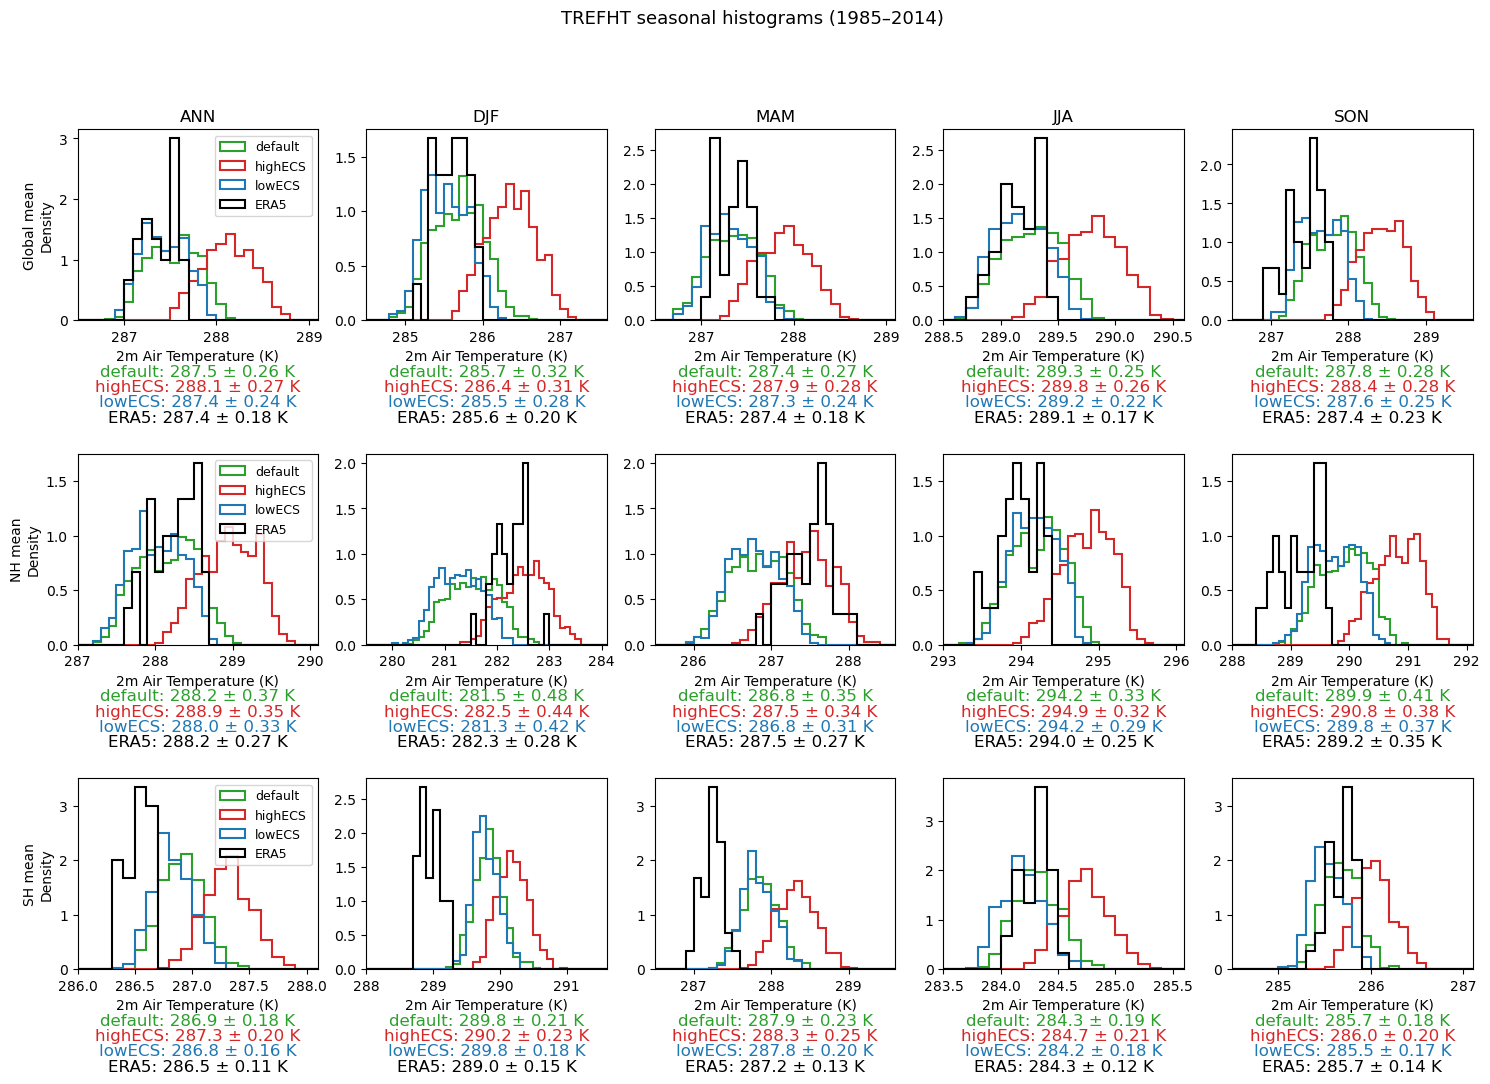

In [58]:
# ── Plot ──────────────────────────────────────────────────────────────────────

# Hand-tuned bins for the global-mean row
GLB_SEASON_BINS = {
    'ANN': np.arange(286.5, 289.0 + 0.1, 0.1),
    'DJF': np.arange(284.5, 287.5 + 0.1, 0.1),
    'MAM': np.arange(286.5, 289.0 + 0.1, 0.1),
    'JJA': np.arange(288.5, 290.5 + 0.1, 0.1),
    'SON': np.arange(286.5, 289.5 + 0.1, 0.1),
}

NH_SEASON_BINS = {
    'ANN': np.arange(287.0, 290.0 + 0.1, 0.1),
    'DJF': np.arange(279.5, 284.0 + 0.1, 0.1),
    'MAM': np.arange(285.5, 288.5 + 0.1, 0.1),
    'JJA': np.arange(293.0, 296.0 + 0.1, 0.1),
    'SON': np.arange(288.0, 292.0 + 0.1, 0.1),
}

SH_SEASON_BINS = {
    'ANN': np.arange(286.0, 288.0 + 0.1, 0.1),
    'DJF': np.arange(288.0, 291.5 + 0.1, 0.1),
    'MAM': np.arange(286.5, 289.5 + 0.1, 0.1),
    'JJA': np.arange(283.5, 285.5 + 0.1, 0.1),
    'SON': np.arange(284.5, 287.0 + 0.1, 0.1),
}

def auto_bins(rgn_key, season, step=0.1, pad=0.5):
    """Derive histogram bins from the data range across all ensembles."""
    all_vals = np.concatenate([v for v, _ in seasonal_data[rgn_key][season].values()])
    lo = np.floor((all_vals.min() - pad) / step) * step
    hi = np.ceil( (all_vals.max() + pad) / step) * step
    return np.arange(lo, hi + step, step)

# Use hand-tuned bins for GLB; auto-derive for NH and SH
SEASON_BINS = {
    rgn_key: {
        season: (GLB_SEASON_BINS[season] if rgn_key == 'GLB'
                 else NH_SEASON_BINS[season] if rgn_key == 'NH'
                 else SH_SEASON_BINS[season] if rgn_key == 'SH'
                 else auto_bins(rgn_key, season))
        for season in HIST_SEASONS
    }
    for rgn_key, _, _ in RGN_SPECS
}

n_rows = len(RGN_SPECS)   # 3
fig, axes = plt.subplots(n_rows, 5, figsize=(18, 4 * n_rows), sharey=False)

for row_idx, (rgn_key, _, row_title) in enumerate(RGN_SPECS):
    for col_idx, season in enumerate(HIST_SEASONS):
        ax   = axes[row_idx, col_idx]
        bins = SEASON_BINS[rgn_key][season]

        for label, _, color in ENSEMBLE_SPECS:
            flat, _ = seasonal_data[rgn_key][season][label]
            ax.hist(flat, bins=bins, histtype='step', color=color, linewidth=1.5, label=label, density=True)

        if row_idx == 0:
            ax.set_title(season, fontsize=12)
        ax.set_xlabel('2m Air Temperature (K)')
        ax.set_xlim(bins[0], bins[-1])

        # --- per-ensemble stats caption below the x-axis label ---
        caption_lines = []
        for label, _, color in ENSEMBLE_SPECS:
            flat, _ = seasonal_data[rgn_key][season][label]
            mu  = np.mean(flat)
            sig = np.std(flat)
            caption_lines.append((f"{label}: {mu:.1f} \u00b1 {sig:.2f} K", color))

        y_start   = -0.23
        line_step = -0.08
        for i, (text, color) in enumerate(caption_lines):
            ax.text(
                0.5, y_start + i * line_step,
                text,
                transform=ax.transAxes,
                ha='center', va='top',
                fontsize=12, color=color,
                clip_on=False,
            )

    axes[row_idx, 0].set_ylabel(f'{row_title}\nDensity')
    axes[row_idx, 0].legend(fontsize=9)

fig.suptitle('TREFHT seasonal histograms (1985–2014)', fontsize=13)
fig.subplots_adjust(bottom=0.18, hspace=0.7)
plt.show()